# Week 8: Final Model Evaluation

## California Property Price Prediction

This notebook performs the final evaluation of the property-price
prediction workflow.

## Leakage-prevention strategy

The evaluation follows these rules:

1. The test dataset is not used for model selection.
2. Missing-value replacement values are calculated using training data only.
3. The final 20% of the training observations is reserved as a chronological validation set.
4. Candidate models are compared using validation RMSE.
5. The selected model is retrained using the complete training dataset.
6. The untouched test dataset is evaluated only after model selection is complete.
7. No test-set metric is used to choose a model or hyperparameter.

## Evaluation metrics

- Mean Absolute Error
- Root Mean Squared Error
- Mean Absolute Percentage Error
- Median Absolute Percentage Error
- R²
- Performance by property-price band

In [2]:
from pathlib import Path
from time import perf_counter
import json
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMRegressor,
    early_stopping as lgb_early_stopping,
    log_evaluation as lgb_log_evaluation,
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

In [3]:
PROJECT_ROOT = Path.cwd().parent

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
SRC_DIR = PROJECT_ROOT / "src"

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

TRAIN_FILE = DATA_DIR / "train_features.csv"
TEST_FILE = DATA_DIR / "test_features.csv"

TARGET_COLUMN = "ClosePrice"
VALIDATION_FRACTION = 0.20
RANDOM_STATE = 42

print(f"Project root: {PROJECT_ROOT}")
print(f"Training file: {TRAIN_FILE}")
print(f"Testing file: {TEST_FILE}")

Project root: C:\Users\sonng\California_Housing_Data
Training file: C:\Users\sonng\California_Housing_Data\data\train_features.csv
Testing file: C:\Users\sonng\California_Housing_Data\data\test_features.csv


In [4]:
if not TRAIN_FILE.exists():
    raise FileNotFoundError(
        f"Training file not found: {TRAIN_FILE}\n"
        "Run src/features.py first."
    )

if not TEST_FILE.exists():
    raise FileNotFoundError(
        f"Testing file not found: {TEST_FILE}\n"
        "Run src/features.py first."
    )

train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

print(f"Training shape: {train_df.shape}")
print(f"Testing shape: {test_df.shape}")

train_df.head()

Training shape: (49703, 989)
Testing shape: (12024, 989)


,ClosePrice,LotSizeSquareFeet,LivingArea,BathroomsTotalInteger,BedroomsTotal,ListPrice,PropertyAge,City_Acampo,City_Acton,City_Adelanto,City_Agoura Hills,City_Agua Dulce,City_Aguanga,City_Ahwahnee,City_Alameda,City_Alamo,City_Albany,City_Albion,City_Alhambra,City_Aliso Viejo,City_Almanor,City_Alpine,City_Alta Loma,City_Altadena,City_Alturas,City_Alviso,City_American Canyon,City_Anaheim,City_Anaheim Hills,City_Anderson,City_Angels Camp,City_Angelus Oaks,City_Angwin,City_Antelope,City_Antioch,City_Anza,City_Apple Valley,City_Aptos,City_Arbuckle,City_Arcadia,City_Arleta,City_Arnold,City_Aromas,City_Arrowbear,City_Arroyo Grande,City_Artesia,City_Artois,City_Arvin,City_Atascadero,City_Atherton,City_Atwater,City_Atwater Village,City_Auberry,City_Auburn,City_Avalon,City_Avenal,City_Avila Beach,City_Azusa,City_Bakersfield,City_Baldwin Hills,City_Baldwin Park,City_Bangor,City_Banning,City_Barstow,City_Bass Lake,City_Bay Point,City_Beaumont,City_Bel Air,City_Bell,City_Bell Canyon,City_Bell Gardens,City_Bellflower,City_Belmont,City_Ben Lomond,City_Benicia,City_Berkeley,City_Bermuda Dunes,City_Berry Creek,City_Bethel Island,City_Beverly Hills,City_Big Bar,City_Big Bear,City_Big Bear City,City_Big Bear Lake,City_Big River,City_Big Sur,City_Biggs,City_Bishop,City_Bloomington,City_Blue Jay,City_Blythe,City_Bodfish,City_Bombay Beach,City_Bonita,City_Bonsall,City_Boron,City_Borrego Springs,City_Boulder Creek,City_Boulevard,City_Bradbury,...,City_Westwood,City_Wheatland,City_Whitewater,City_Whittier,City_Wildomar,City_Williams,City_Willits,City_Willows,City_Wilmington,City_Wilton,City_Winchester,City_Windsor Hills,City_Winnetka,City_Winton,City_Wishon,City_Wofford Heights,City_Woodbridge,City_Woodcrest,City_Woodland,City_Woodland Hills,City_Woodside,City_Wrightwood,City_Yermo,City_Yorba Linda,City_Yosemite,City_Yreka,City_Yuba City,City_Yucaipa,City_Yucca Valley,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,CountyOrParish_San Luis Obispo,CountyOrParish_San Mateo,CountyOrParish_Santa Barbara,CountyOrParish_Santa Clara,CountyOrParish_Santa Cruz,CountyOrParish_Shasta,CountyOrParish_Siskiyou,CountyOrParish_Solano,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,LivingAreaPerBedroom,LivingAreaPerBathroom,BedBathRatio,ListPricePerSquareFoot,LotToLivingAreaRatio,TotalRoomsApprox,OutdoorSpaceApprox,LogLivingArea,LogLotSize,LogListPrice,IsNewProperty,IsRecentProperty,IsOlderProperty,PropertyAgeSquared
0,"1,998,000.0000","10,080.0000","2,045.0000",2.0000,4.0000,"1,998,000.0000",57.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

In [5]:
if TARGET_COLUMN not in train_df.columns:
    raise ValueError(
        f"{TARGET_COLUMN} is missing from training data."
    )

if TARGET_COLUMN not in test_df.columns:
    raise ValueError(
        f"{TARGET_COLUMN} is missing from testing data."
    )

if train_df.empty or test_df.empty:
    raise ValueError(
        "The training or testing dataset is empty."
    )

if train_df.columns.duplicated().any():
    raise ValueError(
        "Training data contains duplicate columns."
    )

if test_df.columns.duplicated().any():
    raise ValueError(
        "Testing data contains duplicate columns."
    )

print("Dataset structure passed validation.")

Dataset structure passed validation.


In [6]:
X_train = train_df.drop(
    columns=[TARGET_COLUMN]
).copy()

X_test = test_df.drop(
    columns=[TARGET_COLUMN]
).copy()

y_train = pd.to_numeric(
    train_df[TARGET_COLUMN],
    errors="coerce",
)

y_test = pd.to_numeric(
    test_df[TARGET_COLUMN],
    errors="coerce",
)

if y_train.isna().any():
    raise ValueError(
        "Training target contains invalid values."
    )

if y_test.isna().any():
    raise ValueError(
        "Testing target contains invalid values."
    )

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0,
)

print(f"Training predictors: {X_train.shape}")
print(f"Testing predictors: {X_test.shape}")

Training predictors: (49703, 988)
Testing predictors: (12024, 988)


In [7]:
training_medians = {}

for column in X_train.columns:
    X_train[column] = pd.to_numeric(
        X_train[column],
        errors="coerce",
    )

    X_test[column] = pd.to_numeric(
        X_test[column],
        errors="coerce",
    )

    X_train[column] = X_train[column].replace(
        [np.inf, -np.inf],
        np.nan,
    )

    X_test[column] = X_test[column].replace(
        [np.inf, -np.inf],
        np.nan,
    )

    # Calculated only from training data.
    training_median = X_train[column].median()

    if pd.isna(training_median):
        training_median = 0.0

    training_medians[column] = float(
        training_median
    )

    X_train[column] = X_train[column].fillna(
        training_median
    ).astype(float)

    X_test[column] = X_test[column].fillna(
        training_median
    ).astype(float)

print(
    "Training missing values:",
    int(X_train.isna().sum().sum()),
)

print(
    "Testing missing values:",
    int(X_test.isna().sum().sum()),
)

Training missing values: 0
Testing missing values: 0


In [8]:
train_array = X_train.to_numpy(dtype=float)
test_array = X_test.to_numpy(dtype=float)

if np.isnan(train_array).any():
    raise ValueError(
        "Training predictors contain NaN values."
    )

if np.isnan(test_array).any():
    raise ValueError(
        "Testing predictors contain NaN values."
    )

if np.isinf(train_array).any():
    raise ValueError(
        "Training predictors contain infinite values."
    )

if np.isinf(test_array).any():
    raise ValueError(
        "Testing predictors contain infinite values."
    )

print("Model matrices passed validation.")

Model matrices passed validation.


## Chronological Model-Selection Split

The test dataset remains untouched.

The final 20% of the training observations is used as a validation
period. The earlier 80% is used to fit candidate models. No random
shuffling is used.

In [10]:
split_index = int(
    len(X_train)
    * (1 - VALIDATION_FRACTION)
)

X_fit = X_train.iloc[:split_index].copy()
X_validation = X_train.iloc[split_index:].copy()

y_fit = y_train.iloc[:split_index].copy()
y_validation = y_train.iloc[split_index:].copy()

print(f"Fitting observations: {len(X_fit):,}")
print(
    f"Validation observations: "
    f"{len(X_validation):,}"
)
print(f"Untouched test observations: {len(X_test):,}")

Fitting observations: 39,762
Validation observations: 9,941
Untouched test observations: 12,024


In [11]:
def calculate_percentage_errors(actual, predicted):
    actual_array = np.asarray(
        actual,
        dtype=float,
    )

    predicted_array = np.asarray(
        predicted,
        dtype=float,
    )

    valid_mask = (
        np.isfinite(actual_array)
        & np.isfinite(predicted_array)
        & (actual_array != 0)
    )

    if not np.any(valid_mask):
        return np.array([], dtype=float)

    return np.abs(
        (
            actual_array[valid_mask]
            - predicted_array[valid_mask]
        )
        / actual_array[valid_mask]
    )


def calculate_mape(actual, predicted):
    errors = calculate_percentage_errors(
        actual,
        predicted,
    )

    if len(errors) == 0:
        return np.nan

    return float(
        np.mean(errors) * 100
    )


def calculate_mdape(actual, predicted):
    errors = calculate_percentage_errors(
        actual,
        predicted,
    )

    if len(errors) == 0:
        return np.nan

    return float(
        np.median(errors) * 100
    )


def calculate_metrics(actual, predicted):
    return {
        "MAE": float(
            mean_absolute_error(
                actual,
                predicted,
            )
        ),
        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    actual,
                    predicted,
                )
            )
        ),
        "MAPE": calculate_mape(
            actual,
            predicted,
        ),
        "MdAPE": calculate_mdape(
            actual,
            predicted,
        ),
        "R2": float(
            r2_score(
                actual,
                predicted,
            )
        ),
    }

In [12]:
reference_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    loss="squared_error",
    random_state=RANDOM_STATE,
)

xgboost_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    early_stopping_rounds=75,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lightgbm_model = LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

In [13]:
reference_start = perf_counter()

reference_model.fit(
    X_fit,
    y_fit,
)

reference_training_seconds = (
    perf_counter() - reference_start
)

reference_validation_predictions = (
    reference_model.predict(X_validation)
)

reference_validation_metrics = calculate_metrics(
    y_validation,
    reference_validation_predictions,
)

print(reference_validation_metrics)

{'MAE': 373525.76586888987, 'RMSE': 12856816.438742224, 'MAPE': 32.52767855942393, 'MdAPE': 6.419838846633022, 'R2': 0.008358943335899816}


In [14]:
xgboost_start = perf_counter()

xgboost_model.fit(
    X_fit,
    y_fit,
    eval_set=[
        (
            X_validation,
            y_validation,
        )
    ],
    verbose=False,
)

xgboost_training_seconds = (
    perf_counter() - xgboost_start
)

xgboost_validation_predictions = (
    xgboost_model.predict(X_validation)
)

xgboost_validation_metrics = calculate_metrics(
    y_validation,
    xgboost_validation_predictions,
)

xgboost_best_iterations = getattr(
    xgboost_model,
    "best_iteration",
    None,
)

if xgboost_best_iterations is not None:
    xgboost_best_iterations = (
        int(xgboost_best_iterations) + 1
    )

print(xgboost_validation_metrics)
print(
    "Selected boosting rounds:",
    xgboost_best_iterations,
)

{'MAE': 402433.95333433663, 'RMSE': 12804287.379970169, 'MAPE': 37.96064895511583, 'MdAPE': 8.153923766816144, 'R2': 0.016445480103262744}
Selected boosting rounds: 72


In [15]:
lightgbm_callbacks = [
    lgb_early_stopping(
        stopping_rounds=75,
        first_metric_only=True,
        verbose=False,
    ),
    lgb_log_evaluation(
        period=0,
    ),
]

lightgbm_start = perf_counter()

lightgbm_model.fit(
    X_fit,
    y_fit,
    eval_set=[
        (
            X_validation,
            y_validation,
        )
    ],
    eval_metric="rmse",
    callbacks=lightgbm_callbacks,
)

lightgbm_training_seconds = (
    perf_counter() - lightgbm_start
)

lightgbm_validation_predictions = (
    lightgbm_model.predict(X_validation)
)

lightgbm_validation_metrics = calculate_metrics(
    y_validation,
    lightgbm_validation_predictions,
)

lightgbm_best_iterations = getattr(
    lightgbm_model,
    "best_iteration_",
    None,
)

if lightgbm_best_iterations is not None:
    lightgbm_best_iterations = int(
        lightgbm_best_iterations
    )

print(lightgbm_validation_metrics)
print(
    "Selected boosting rounds:",
    lightgbm_best_iterations,
)

{'MAE': 493001.1352174412, 'RMSE': 12856395.897175403, 'MAPE': 48.8233533675206, 'MdAPE': 16.53793728414715, 'R2': 0.008423814677151809}
Selected boosting rounds: 42


In [16]:
validation_metrics = pd.DataFrame(
    [
        {
            "Model": "Gradient Boosting",
            **reference_validation_metrics,
            "TrainingSeconds": (
                reference_training_seconds
            ),
        },
        {
            "Model": "XGBoost",
            **xgboost_validation_metrics,
            "TrainingSeconds": (
                xgboost_training_seconds
            ),
        },
        {
            "Model": "LightGBM",
            **lightgbm_validation_metrics,
            "TrainingSeconds": (
                lightgbm_training_seconds
            ),
        },
    ]
)

validation_metrics = validation_metrics.sort_values(
    by=["RMSE", "R2"],
    ascending=[True, False],
).reset_index(drop=True)

validation_metrics

,Model,MAE,RMSE,MAPE,MdAPE,R2,TrainingSeconds
0,XGBoost,"402,433.9533","12,804,287.3800",37.9606,8.1539,0.0164,9.2406
1,LightGBM,"493,001.1352","12,856,395.8972",48.8234,16.5379,0.0084,1.5193
2,Gradient Boosting,"373,525.7659","12,856,816.4387",32.5277,6.4198,0.0084,213.0303


In [17]:
selected_model_name = validation_metrics.loc[
    0,
    "Model",
]

print(
    "Selected model using validation data:",
    selected_model_name,
)

Selected model using validation data: XGBoost


In [18]:
if selected_model_name == "Gradient Boosting":
    final_model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5,
        loss="squared_error",
        random_state=RANDOM_STATE,
    )

elif selected_model_name == "XGBoost":
    final_iterations = (
        xgboost_best_iterations or 500
    )

    final_model = XGBRegressor(
        n_estimators=final_iterations,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=3,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

elif selected_model_name == "LightGBM":
    final_iterations = (
        lightgbm_best_iterations or 500
    )

    final_model = LGBMRegressor(
        objective="regression",
        n_estimators=final_iterations,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )

else:
    raise ValueError(
        f"Unknown model: {selected_model_name}"
    )

final_training_start = perf_counter()

final_model.fit(
    X_train,
    y_train,
)

final_training_seconds = (
    perf_counter() - final_training_start
)

print(
    f"Final model trained in "
    f"{final_training_seconds:.2f} seconds."
)

Final model trained in 5.72 seconds.


In [19]:
# This is the first point at which the test set is used.

prediction_start = perf_counter()

test_predictions = final_model.predict(
    X_test
)

prediction_seconds = (
    perf_counter() - prediction_start
)

print(
    f"Test predictions completed in "
    f"{prediction_seconds:.4f} seconds."
)

Test predictions completed in 0.1540 seconds.


In [20]:
test_metrics = calculate_metrics(
    y_test,
    test_predictions,
)

metrics_summary = pd.DataFrame(
    [
        {
            "EvaluationSet": "Untouched Test Set",
            "SelectedModel": selected_model_name,
            **test_metrics,
            "TrainingSeconds": final_training_seconds,
            "PredictionSeconds": prediction_seconds,
            "TrainingObservations": len(X_train),
            "TestObservations": len(X_test),
            "FeatureCount": X_train.shape[1],
        }
    ]
)

metrics_summary

,EvaluationSet,SelectedModel,MAE,RMSE,MAPE,MdAPE,R2,TrainingSeconds,PredictionSeconds,TrainingObservations,TestObservations,FeatureCount
0,Untouched Test Set,XGBoost,"251,555.6037","2,068,142.5960",33.8267,10.0910,-0.5190,5.7157,0.1540,49703,12024,988


In [21]:
print("Final Untouched-Test Results")
print("=" * 50)
print(f"Model: {selected_model_name}")
print(f"MAE: ${test_metrics['MAE']:,.2f}")
print(f"RMSE: ${test_metrics['RMSE']:,.2f}")
print(f"MAPE: {test_metrics['MAPE']:.2f}%")
print(f"MdAPE: {test_metrics['MdAPE']:.2f}%")
print(f"R²: {test_metrics['R2']:.4f}")

Final Untouched-Test Results
Model: XGBoost
MAE: $251,555.60
RMSE: $2,068,142.60
MAPE: 33.83%
MdAPE: 10.09%
R²: -0.5190


In [22]:
prediction_results = pd.DataFrame(
    {
        "ActualClosePrice": (
            y_test.reset_index(drop=True)
        ),
        "PredictedClosePrice": (
            test_predictions
        ),
    }
)

prediction_results["Residual"] = (
    prediction_results["ActualClosePrice"]
    - prediction_results["PredictedClosePrice"]
)

prediction_results["AbsoluteError"] = (
    prediction_results["Residual"].abs()
)

prediction_results["AbsolutePercentageError"] = np.where(
    prediction_results["ActualClosePrice"] != 0,
    (
        prediction_results["AbsoluteError"]
        / prediction_results["ActualClosePrice"]
    )
    * 100,
    np.nan,
)

prediction_results.head(10)

,ActualClosePrice,PredictedClosePrice,Residual,AbsoluteError,AbsolutePercentageError
0,"8,712,500.0000","7,517,883.5000","1,194,616.5000","1,194,616.5000",13.7115
1,"1,100,000.0000","1,066,438.3750","33,561.6250","33,561.6250",3.0511
2,"1,625,000.0000","1,362,919.0000","262,081.0000","262,081.0000",16.1281
3,"1,560,000.0000","1,599,175.6250","-39,175.6250","39,175.6250",2.5113
4,"605,000.0000","679,082.2500","-74,082.2500","74,082.2500",12.2450
5,"377,500.0000","581,858.0000","-204,358.0000","204,358.0000",54.1346
6,"400,000.0000","585,516.8750","-185,516.8750","185,516.8750",46.3792
7,"595,000.0000","666,371.6875","-71,371.6875","71,371.6875",11.9952
8,"595,000.0000","660,546.0000","-65,546.0000","65,546.0000",11.0161
9,"2,400,000.0000","2,258,172.2500","141,827.7500","141,827.7500",5.9095


In [23]:
price_bins = [
    -np.inf,
    500_000,
    1_000_000,
    2_000_000,
    5_000_000,
    np.inf,
]

price_labels = [
    "Under $500K",
    "$500K-$1M",
    "$1M-$2M",
    "$2M-$5M",
    "$5M+",
]

prediction_results["PriceBand"] = pd.cut(
    prediction_results["ActualClosePrice"],
    bins=price_bins,
    labels=price_labels,
    right=False,
)

prediction_results[
    "PriceBand"
].value_counts(sort=False)

PriceBand
Under $500K    1644
$500K-$1M      4881
$1M-$2M        3780
$2M-$5M        1518
$5M+            201
Name: count, dtype: int64

In [24]:
price_band_rows = []

for price_band, band_df in prediction_results.groupby(
    "PriceBand",
    observed=False,
):
    if band_df.empty:
        continue

    band_metrics = calculate_metrics(
        band_df["ActualClosePrice"],
        band_df["PredictedClosePrice"].to_numpy(),
    )

    price_band_rows.append(
        {
            "PriceBand": str(price_band),
            "ObservationCount": len(band_df),
            **band_metrics,
        }
    )

price_band_metrics = pd.DataFrame(
    price_band_rows
)

price_band_metrics

,PriceBand,ObservationCount,MAE,RMSE,MAPE,MdAPE,R2
0,Under $500K,1644,"245,850.6801","312,487.6930",100.8994,50.2262,-11.4467
1,$500K-$1M,4881,"280,426.2836","2,743,624.8851",39.4819,13.4342,-393.3642
2,$1M-$2M,3780,"111,129.1472","746,945.0674",8.0237,4.1973,-6.7833
3,$2M-$5M,1518,"294,117.1793","386,277.3073",9.8577,8.1427,0.7495
4,$5M+,201,"1,916,553.8109","7,788,115.0414",14.1753,11.9817,0.1190


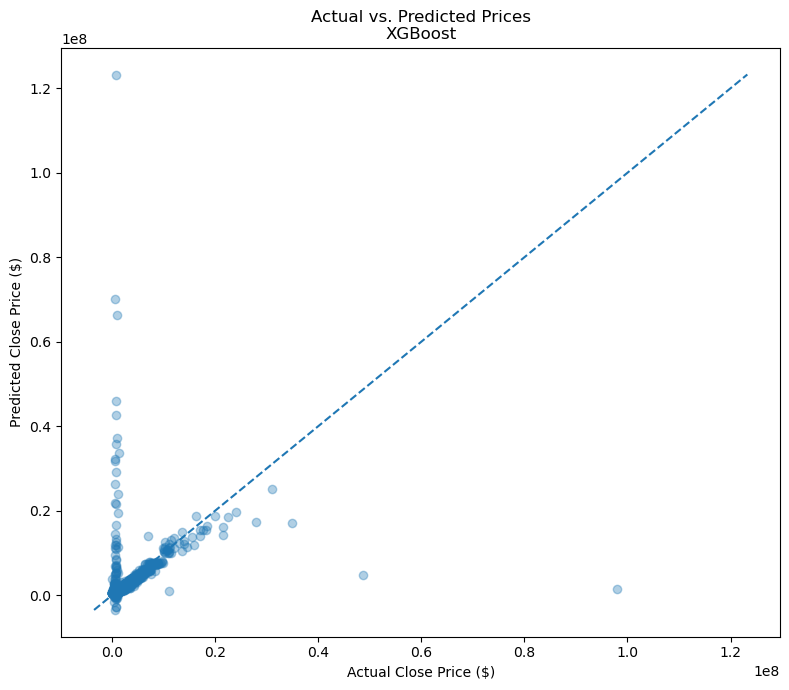

In [25]:
minimum_price = min(
    prediction_results["ActualClosePrice"].min(),
    prediction_results["PredictedClosePrice"].min(),
)

maximum_price = max(
    prediction_results["ActualClosePrice"].max(),
    prediction_results["PredictedClosePrice"].max(),
)

plt.figure(figsize=(8, 7))

plt.scatter(
    prediction_results["ActualClosePrice"],
    prediction_results["PredictedClosePrice"],
    alpha=0.35,
)

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--",
)

plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title(
    f"Actual vs. Predicted Prices\n"
    f"{selected_model_name}"
)

plt.tight_layout()
plt.show()

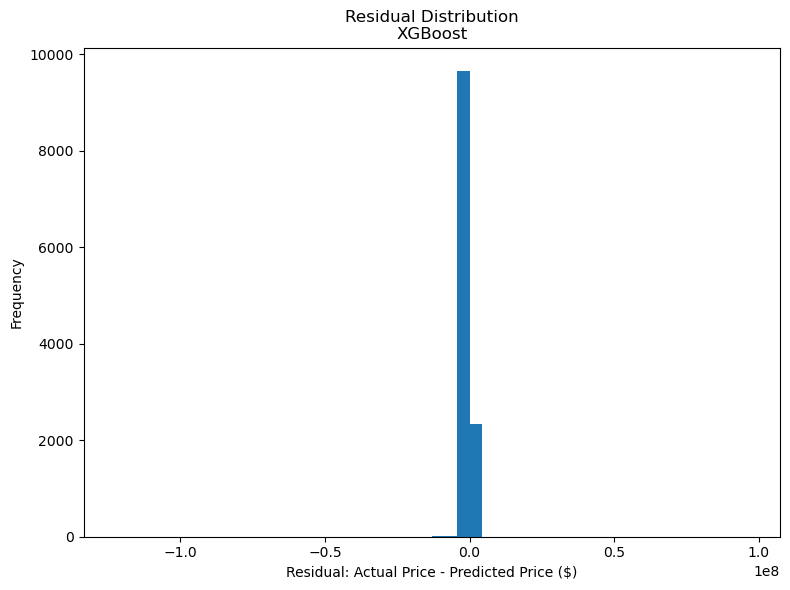

In [26]:
plt.figure(figsize=(8, 6))

plt.hist(
    prediction_results["Residual"],
    bins=50,
)

plt.xlabel(
    "Residual: Actual Price - Predicted Price ($)"
)

plt.ylabel("Frequency")

plt.title(
    f"Residual Distribution\n"
    f"{selected_model_name}"
)

plt.tight_layout()
plt.show()

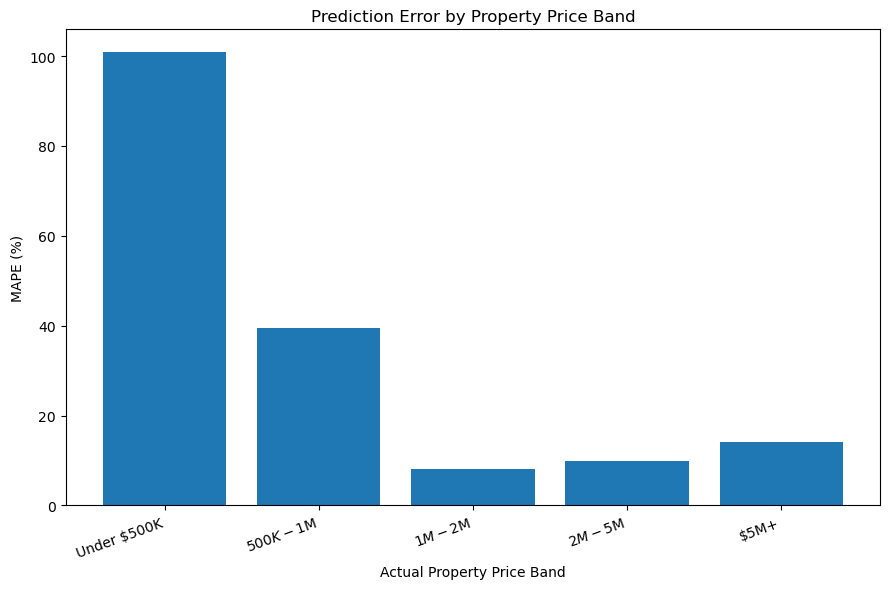

In [27]:
plt.figure(figsize=(9, 6))

plt.bar(
    price_band_metrics["PriceBand"],
    price_band_metrics["MAPE"],
)

plt.xlabel("Actual Property Price Band")
plt.ylabel("MAPE (%)")
plt.title(
    "Prediction Error by Property Price Band"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()
plt.show()

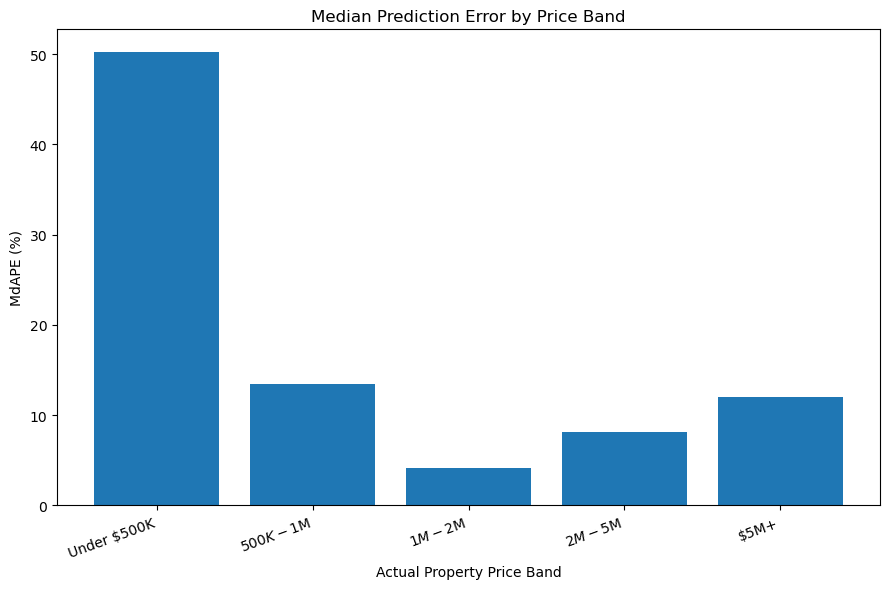

In [28]:
plt.figure(figsize=(9, 6))

plt.bar(
    price_band_metrics["PriceBand"],
    price_band_metrics["MdAPE"],
)

plt.xlabel("Actual Property Price Band")
plt.ylabel("MdAPE (%)")
plt.title(
    "Median Prediction Error by Price Band"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()
plt.show()

In [29]:
largest_errors = prediction_results.sort_values(
    by="AbsoluteError",
    ascending=False,
).head(20)

largest_errors

,ActualClosePrice,PredictedClosePrice,Residual,AbsoluteError,AbsolutePercentageError,PriceBand
6421,"735,000.0000","123,262,184.0000","-122,527,184.0000","122,527,184.0000","16,670.3652",$500K-$1M
10192,"97,972,500.0000","1,521,714.8750","96,450,785.1250","96,450,785.1250",98.4468,$5M+
11701,"629,000.0000","70,042,064.0000","-69,413,064.0000","69,413,064.0000","11,035.4633",$500K-$1M
6793,"900,000.0000","66,378,136.0000","-65,478,136.0000","65,478,136.0000","7,275.3484",$500K-$1M
11458,"877,000.0000","45,954,640.0000","-45,077,640.0000","45,077,640.0000","5,139.9818",$500K-$1M
8125,"48,720,000.0000","4,924,238.5000","43,795,761.5000","43,795,761.5000",89.8928,$5M+
11425,"712,500.0000","42,745,444.0000","-42,032,944.0000","42,032,944.0000","5,899.3606",$500K-$1M
7598,"900,000.0000","37,276,584.0000","-36,376,584.0000","36,376,584.0000","4,041.8427",$500K-$1M
889,"847,500.0000","35,885,668.0000","-35,038,168.0000","35,038,168.0000","4,134.2971",$500K-$1M
4689,"1,350,000.0000","33,738,912.0000","-32,388,912.0000","32,388,912.0000","2,399.1787",$1M-$2M


In [30]:
final_model_artifact = {
    "model_name": selected_model_name,
    "model": final_model,
    "feature_names": X_train.columns.tolist(),
    "training_medians": training_medians,
    "target_column": TARGET_COLUMN,
}

final_model_file = (
    MODELS_DIR / "final_evaluated_model.pkl"
)

joblib.dump(
    final_model_artifact,
    final_model_file,
)

print(f"Saved: {final_model_file}")

Saved: C:\Users\sonng\California_Housing_Data\models\final_evaluated_model.pkl


In [31]:
metrics_file = (
    REPORTS_DIR / "metrics_summary.csv"
)

price_band_file = (
    REPORTS_DIR / "price_band_metrics.csv"
)

predictions_file = (
    REPORTS_DIR / "final_test_predictions.csv"
)

metrics_summary.to_csv(
    metrics_file,
    index=False,
)

price_band_metrics.to_csv(
    price_band_file,
    index=False,
)

prediction_results.to_csv(
    predictions_file,
    index=False,
)

print(f"Saved: {metrics_file}")
print(f"Saved: {price_band_file}")
print(f"Saved: {predictions_file}")

Saved: C:\Users\sonng\California_Housing_Data\reports\metrics_summary.csv
Saved: C:\Users\sonng\California_Housing_Data\reports\price_band_metrics.csv
Saved: C:\Users\sonng\California_Housing_Data\reports\final_test_predictions.csv


In [32]:
model_metadata = {
    "selected_model": selected_model_name,
    "selection_source": (
        "Chronological validation subset from training data"
    ),
    "final_evaluation_source": (
        "Untouched chronological test set"
    ),
    "validation_fraction": VALIDATION_FRACTION,
    "training_observations": int(len(X_train)),
    "test_observations": int(len(X_test)),
    "feature_count": int(X_train.shape[1]),
    "test_metrics": {
        key: float(value)
        for key, value in test_metrics.items()
    },
}

metadata_file = (
    REPORTS_DIR / "final_model_metadata.json"
)

with open(
    metadata_file,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_metadata,
        file,
        indent=4,
    )

print(f"Saved: {metadata_file}")

Saved: C:\Users\sonng\California_Housing_Data\reports\final_model_metadata.json


In [33]:
actual_predicted_file = (
    REPORTS_DIR / "actual_vs_predicted.png"
)

residual_file = (
    REPORTS_DIR / "residual_distribution.png"
)

price_band_mape_file = (
    REPORTS_DIR / "price_band_mape.png"
)

plt.figure(figsize=(8, 7))

plt.scatter(
    prediction_results["ActualClosePrice"],
    prediction_results["PredictedClosePrice"],
    alpha=0.35,
)

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--",
)

plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title(
    f"Actual vs. Predicted Prices\n"
    f"{selected_model_name}"
)

plt.tight_layout()

plt.savefig(
    actual_predicted_file,
    dpi=300,
    bbox_inches="tight",
)

plt.close()


plt.figure(figsize=(8, 6))

plt.hist(
    prediction_results["Residual"],
    bins=50,
)

plt.xlabel(
    "Residual: Actual Price - Predicted Price ($)"
)

plt.ylabel("Frequency")

plt.title(
    f"Residual Distribution\n"
    f"{selected_model_name}"
)

plt.tight_layout()

plt.savefig(
    residual_file,
    dpi=300,
    bbox_inches="tight",
)

plt.close()


plt.figure(figsize=(9, 6))

plt.bar(
    price_band_metrics["PriceBand"],
    price_band_metrics["MAPE"],
)

plt.xlabel("Actual Property Price Band")
plt.ylabel("MAPE (%)")
plt.title(
    "Prediction Error by Property Price Band"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    price_band_mape_file,
    dpi=300,
    bbox_inches="tight",
)

plt.close()

print(f"Saved: {actual_predicted_file}")
print(f"Saved: {residual_file}")
print(f"Saved: {price_band_mape_file}")

Saved: C:\Users\sonng\California_Housing_Data\reports\actual_vs_predicted.png
Saved: C:\Users\sonng\California_Housing_Data\reports\residual_distribution.png
Saved: C:\Users\sonng\California_Housing_Data\reports\price_band_mape.png


In [34]:
best_band = price_band_metrics.sort_values(
    by="MAPE",
    ascending=True,
).iloc[0]

worst_band = price_band_metrics.sort_values(
    by="MAPE",
    ascending=False,
).iloc[0]

print("Week 8 Evaluation Summary")
print("=" * 60)

print(
    f"The final model selected using validation data "
    f"was {selected_model_name}."
)

print(
    f"On the untouched test set, the model achieved "
    f"an R² of {test_metrics['R2']:.4f}."
)

print(
    f"The average absolute percentage error was "
    f"{test_metrics['MAPE']:.2f}%."
)

print(
    f"The median absolute percentage error was "
    f"{test_metrics['MdAPE']:.2f}%."
)

print(
    f"The strongest-performing price band by MAPE was "
    f"{best_band['PriceBand']} "
    f"with a MAPE of {best_band['MAPE']:.2f}%."
)

print(
    f"The weakest-performing price band by MAPE was "
    f"{worst_band['PriceBand']} "
    f"with a MAPE of {worst_band['MAPE']:.2f}%."
)

Week 8 Evaluation Summary
The final model selected using validation data was XGBoost.
On the untouched test set, the model achieved an R² of -0.5190.
The average absolute percentage error was 33.83%.
The median absolute percentage error was 10.09%.
The strongest-performing price band by MAPE was $1M-$2M with a MAPE of 8.02%.
The weakest-performing price band by MAPE was Under $500K with a MAPE of 100.90%.


# Week 8 Summary

A leakage-safe final evaluation was completed.

## Model-selection procedure

Candidate models were compared using a chronological validation subset
created from the training period. The test dataset was not used to
select the model or determine the number of boosting rounds.

After selection, the winning model was retrained using the complete
training dataset and evaluated once on the untouched test dataset.

## Metrics reported

- Mean Absolute Error
- Root Mean Squared Error
- Mean Absolute Percentage Error
- Median Absolute Percentage Error
- R²

## Price-band analysis

Performance was also measured across fixed property-price bands:

- Under $500,000
- $500,000 to $1 million
- $1 million to $2 million
- $2 million to $5 million
- $5 million and above

This analysis identifies the property-value ranges in which the model
is most and least reliable.

## Week 8 outputs

- `reports/metrics_summary.csv`
- `reports/price_band_metrics.csv`
- `reports/final_test_predictions.csv`
- `reports/final_model_metadata.json`
- `models/final_evaluated_model.pkl`
- Evaluation figures

The next optional step is Week 9, where the final model can be connected
to a Streamlit prediction application.